In [1]:
# Postfit uncertainty decomposition -- reviewer question (London, Sec 4.2)
#
# The full postfit Hesse covariance from the Asimov fit spans all 95
# parameters: 7 dpT template parameters + 52 cross-section + 27 flux +
# 9 detector nuisances. For a Gaussian posterior, the contribution of a
# nuisance family F to the template-parameter uncertainty is obtained by
# conditioning:
#
#   Sigma_cc|F = Sigma_cc - Sigma_cF Sigma_FF^-1 Sigma_Fc
#   contribution_i = sqrt( sigma_i^2(total) - sigma_i^2(conditioned) )
#
# This is mathematically equivalent to refitting with the family fixed and
# subtracting in quadrature, but needs no refits. The residual after
# conditioning on ALL nuisances is the statistical-like component.
# Template values are 1 in the Asimov fit, so sigma is directly fractional.

import uproot
import numpy as np

FITTER_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_GUNDAM/data/Fitter/dpT/Asimov/asimov_dpT.root"
)
EDGES = ["0.00-0.08", "0.08-0.16", "0.16-0.24", "0.24-0.32",
         "0.32-0.52", "0.52-0.80"]

f = uproot.open(FITTER_FILE)
h = f["FitterEngine/postFit/Hesse/hessian/postfitCovariance_TH2D"]
cov = h.values()
labels = list(h.axis(0).labels())

# The seventh template parameter is the overflow bin (dpT > 0.8 GeV/c)
# and is not part of the measurement -- excluded from the decomposition.
tpl = [i for i, l in enumerate(labels) if "Template" in l and not l.endswith("#6")]
fam = {"xsec": [i for i, l in enumerate(labels) if "Cross section" in l],
       "flux": [i for i, l in enumerate(labels) if "Flux" in l],
       "det":  [i for i, l in enumerate(labels) if "Detector" in l]}
print(f"{len(labels)} parameters: {len(tpl)} templates, "
      + ", ".join(f"{k}: {len(v)}" for k, v in fam.items()))

Scc = cov[np.ix_(tpl, tpl)]
tot = np.sqrt(np.diag(Scc))

def family_contribution(idx):
    Sff = cov[np.ix_(idx, idx)]
    Scf = cov[np.ix_(tpl, idx)]
    cond = Scc - Scf @ np.linalg.pinv(Sff) @ Scf.T
    return np.sqrt(np.clip(np.diag(Scc) - np.diag(cond), 0, None)), cond

contrib = {k: family_contribution(v)[0] for k, v in fam.items()}
_, cond_all = family_contribution(fam["xsec"] + fam["flux"] + fam["det"])
stat = np.sqrt(np.clip(np.diag(cond_all), 0, None))

print(f"\n{'true dpT bin':>12} {'total':>7} {'xsec':>7} {'flux':>7} "
      f"{'det':>7} {'stat':>7}   [% on template parameter]")
for i, lab in enumerate(EDGES):
    print(f"{lab:>12} {100*tot[i]:>6.1f} {100*contrib['xsec'][i]:>6.1f} "
          f"{100*contrib['flux'][i]:>6.1f} {100*contrib['det'][i]:>6.1f} "
          f"{100*stat[i]:>6.1f}")
print("\nPrefit yield-level uncertainties for comparison: "
      "xsec ~20.1%, flux ~8.4%, detector ~7.8% (technote Sec. 4).")


95 parameters: 6 templates, xsec: 52, flux: 27, det: 9

true dpT bin   total    xsec    flux     det    stat   [% on template parameter]
   0.00-0.08   11.4   10.6    3.4    2.3    3.1
   0.08-0.16   11.0   10.5    2.6    1.4    3.1
   0.16-0.24   11.8   11.1    1.6    0.6    3.6
   0.24-0.32   11.4    9.8    3.1    2.3    5.2
   0.32-0.52   11.4   11.0    3.1    2.6    2.3
   0.52-0.80   13.6   13.2    2.1    4.5    2.5

Prefit yield-level uncertainties for comparison: xsec ~20.1%, flux ~8.4%, detector ~7.8% (technote Sec. 4).


In [2]:
# Per-dial contribution to each template-parameter uncertainty.
# For a single dial d the conditioning reduces to a closed form:
#   contribution_i = |cov(c_i, d)| / sqrt(var(d))
# Contributions do not sum to the total across dials because the
# nuisances are correlated postfit -- they rank the dials.

def short(l):
    s = l.split("/")[-1]
    for p in ["GENIEReWeight_SBN_v1_multisigma_", "Synthetic_multisigma_", "#"]:
        s = s.replace(p, "")
    return s

rows = []
for name, idx in fam.items():
    for j in idx:
        c = np.abs(cov[tpl, j]) / np.sqrt(cov[j, j])
        rows.append((name, short(labels[j]), c))

rows.sort(key=lambda r: -r[2].mean())
print(f"{'family':>6} {'dial':>28} " +
      " ".join(f"b{i}" for i in range(len(tpl))) + "   [%]")
for name, dial, c in rows[:25]:
    print(f"{name:>6} {dial:>28} " +
          " ".join(f"{100*v:4.1f}" for v in c))

with open("postfit_dial_contributions.txt", "w") as fh:
    fh.write("family dial " + " ".join(f"bin{i}" for i in range(len(tpl))) + "  [fractional]\n")
    for name, dial, c in rows:
        fh.write(f"{name} {dial} " + " ".join(f"{v:.4f}" for v in c) + "\n")
print("\nfull list -> postfit_dial_contributions.txt")


family                         dial b0 b1 b2 b3 b4 b5   [%]
  xsec                  6_NormCCRES  4.5  4.4  4.2  7.0  7.6  8.6
  xsec                   4_RPA_CCQE  0.5  2.1  5.6  3.3  5.9  7.1
  xsec                     43_MFP_N  2.1  3.1  3.1  3.3  4.7  6.3
  xsec 3_ZExpPCAWeighter_myreweighter_b4  5.7  5.3  4.7  2.9  2.3  1.4
  xsec 2_ZExpPCAWeighter_myreweighter_b3  4.9  4.6  4.1  2.7  2.3  1.5
  xsec 1_ZExpPCAWeighter_myreweighter_b2  4.2  3.8  3.8  2.8  2.6  2.0
   det                      8_var09  2.1  1.2  0.1  1.6  2.2  3.9
  xsec                  41_FrAbs_pi  0.7  0.3  0.5  2.4  2.6  3.7
  xsec                   10_MaCCRES  0.3  0.4  0.3  2.2  2.5  3.6
  xsec                  39_FrCEx_pi  0.3  0.5  0.4  2.5  2.0  2.4
  xsec                   11_MvCCRES  0.4  0.3  0.0  1.9  1.9  2.9
  flux              12_hysyst_hpc_0  2.4  1.6  0.8  0.4  0.6  0.8
  flux              16_hysyst_hpc_4  1.3  1.1  0.7  0.9  1.1  0.8
  xsec                   46_FrAbs_N  0.5  0.4  0.1  2.1  1.0  1.6
 

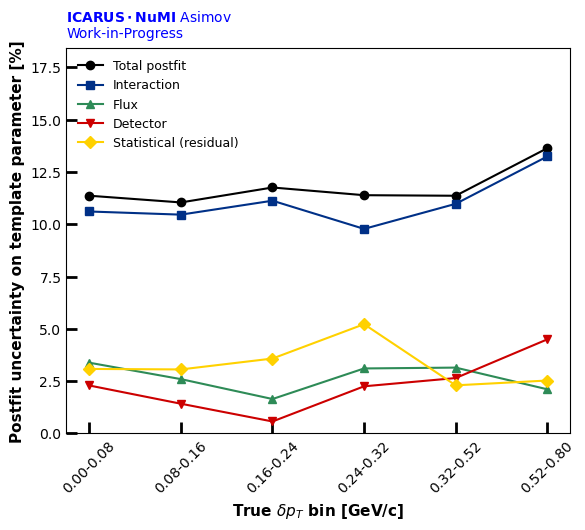

In [3]:
# Prefit vs postfit family summary plot (ICARUS house style)
import os
import matplotlib.pyplot as plt

NAVY, GOLD, RED, GREEN = "#003087", "#FFD100", "#CC0000", "#2E8B57"
centers = np.arange(len(tpl))
fig, ax = plt.subplots(figsize=(6.5, 5))
for series, lab, c, m in [(100*tot, "Total postfit", "black", "o"),
                          (100*contrib["xsec"], "Interaction", NAVY, "s"),
                          (100*contrib["flux"], "Flux", GREEN, "^"),
                          (100*contrib["det"], "Detector", RED, "v"),
                          (100*stat, "Statistical (residual)", GOLD, "D")]:
    ax.plot(centers, series, marker=m, color=c, label=lab, lw=1.5)
ax.set_xticks(centers)
ax.set_xticklabels(EDGES, rotation=45, fontsize=9)
ax.set_xlabel(r"True $\delta p_T$ bin [GeV/c]", fontsize=11, fontweight="bold")
ax.set_ylabel("Postfit uncertainty on template parameter [%]",
              fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.35 * 100 * tot.max())
ax.tick_params(axis="both", which="major", labelsize=10, size=8, width=2, direction="in")
ax.legend(fontsize=9, framealpha=0.0, edgecolor="none")
ax.text(ax.get_xlim()[0], ax.get_ylim()[1] * 1.02,
        r"$\bf{ICARUS \cdot NuMI}$ Asimov" + "\nWork-in-Progress",
        fontsize=10, color="blue", va="bottom")
os.makedirs("pdf", exist_ok=True); os.makedirs("jpeg", exist_ok=True)
fig.savefig("pdf/postfit_uncertainty_decomposition.pdf", bbox_inches="tight", dpi=300)
fig.savefig("jpeg/postfit_uncertainty_decomposition.jpeg", bbox_inches="tight", dpi=300)
plt.show()


In [ ]:
# Single-number summary: contribution to the INTEGRATED cross section.
# The total xsec is proportional to sum_i c_i * T_i with T_i the nominal
# true signal counts per truth bin, so the fractional uncertainty on the
# total is sqrt(W' S W)/sum(W) with W = T. Bin correlations matter: the
# interaction dials move all bins together, so the integrated number does
# NOT average down like uncorrelated bins would.
# (Fit parameters only -- flux-integral and N-targets normalizations enter
# separately in the extraction.)

SIG_FILE = (
    "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
    "My Drive/\U0001F3DB PhD Repository/\U0001F680 Research/\U0001F916 Experiments&Projects/"
    "ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
)
tsig = uproot.open(SIG_FILE)["events/full/signal"]
dtruth = tsig.arrays(["true_dpT_lp_genie"], library="np")["true_dpT_lp_genie"]
W, _ = np.histogram(dtruth, bins=np.array([0., 80., 160., 240., 320., 520., 800.]))
W = W.astype(float)
print("true signal counts per bin:", W.astype(int))

def cond_matrix(idx):
    Sff = cov[np.ix_(idx, idx)]
    Scf = cov[np.ix_(tpl, idx)]
    return Scc - Scf @ np.linalg.pinv(Sff) @ Scf.T

def frac_total(S):
    return np.sqrt(max(W @ S @ W, 0)) / W.sum()

print(f"\nIntegrated cross section (fit part):")
print(f"  total postfit:      {100*frac_total(Scc):.1f}%")
for name, idx in fam.items():
    print(f"  {name:>4} contribution:  {100*frac_total(Scc - cond_matrix(idx)):.1f}%")
print(f"  stat-like residual: "
      f"{100*frac_total(cond_matrix(fam['xsec']+fam['flux']+fam['det'])):.1f}%")
